In [1]:
!pip install -q datasets transformers rouge-score bert-score nltk evaluate

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00


In [2]:
import os
import re
import math
import random
import numpy as np
import torch
import nltk
import matplotlib.pyplot as plt
from collections import defaultdict

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

os.makedirs("figures", exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Colab Free için subset boyutu
# BART inference için GPU lazım ama büyük fine-tune yapmıyoruz
SUBSET_SIZE = 500   # test için kullanılacak örnek sayısı
QUAL_N      = 3     # qualitative örnek sayısı

Device: cuda


In [3]:
from datasets import load_dataset

print("CNN/DailyMail yükleniyor...")
cnn_dm = load_dataset("cnn_dailymail", "3.0.0")

# Subset al
test_data = cnn_dm["test"].shuffle(seed=SEED).select(range(SUBSET_SIZE))

articles  = test_data["article"]
summaries = test_data["highlights"]

print(f"Test subset : {len(test_data)} örnek")
print(f"Ort. makale uzunluğu : {np.mean([len(a.split()) for a in articles]):.0f} kelime")
print(f"Ort. özet uzunluğu   : {np.mean([len(s.split()) for s in summaries]):.0f} kelime")


CNN/DailyMail yükleniyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

...

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

Test subset : 500 örnek
Ort. makale uzunluğu : 687 kelime
Ort. özet uzunluğu   : 56 kelime


In [4]:
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

# BERTScore — lazy load (GPU varsa GPU'da çalışır)
def compute_all_metrics(predictions, references, model_name="Model"):
    """ROUGE, BLEU, METEOR, BERTScore hesapla."""
    print(f"\nMetrikler hesaplanıyor: {model_name}...")

    # ── ROUGE ────────────────────────────────────────────────────────────────
    scorer = rouge_scorer.RougeScorer(["rouge1","rouge2","rougeL"], use_stemmer=True)
    r1_scores, r2_scores, rl_scores = [], [], []
    for pred, ref in zip(predictions, references):
        s = scorer.score(ref, pred)
        r1_scores.append(s["rouge1"].fmeasure)
        r2_scores.append(s["rouge2"].fmeasure)
        rl_scores.append(s["rougeL"].fmeasure)
    rouge1 = np.mean(r1_scores)
    rouge2 = np.mean(r2_scores)
    rougeL = np.mean(rl_scores)

    # ── BLEU ─────────────────────────────────────────────────────────────────
    refs_tok  = [[word_tokenize(r.lower())] for r in references]
    preds_tok = [word_tokenize(p.lower()) for p in predictions]
    smooth = SmoothingFunction().method1
    bleu = corpus_bleu(refs_tok, preds_tok, smoothing_function=smooth)

    # ── METEOR ───────────────────────────────────────────────────────────────
    meteor_scores = []
    for pred, ref in zip(predictions, references):
        score = meteor_score([word_tokenize(ref.lower())],
                              word_tokenize(pred.lower()))
        meteor_scores.append(score)
    meteor = np.mean(meteor_scores)

    # ── BERTScore ────────────────────────────────────────────────────────────
    from bert_score import score as bert_score_fn
    P, R, F1 = bert_score_fn(predictions, references,
                               lang="en", device=str(DEVICE),
                               verbose=False)
    bertscore = F1.mean().item()

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"  ROUGE-1  : {rouge1:.4f}")
    print(f"  ROUGE-2  : {rouge2:.4f}")
    print(f"  ROUGE-L  : {rougeL:.4f}")
    print(f"  BLEU     : {bleu:.4f}")
    print(f"  METEOR   : {meteor:.4f}")
    print(f"  BERTScore: {bertscore:.4f}")
    print(f"{'='*55}")

    return {
        "rouge1": rouge1, "rouge2": rouge2, "rougeL": rougeL,
        "bleu": bleu, "meteor": meteor, "bertscore": bertscore
    }

In [10]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')  # WordNet'in düzgün çalışması için ek bir paket
print("\n" + "█"*60)
print("  MODEL 1: TextRank (Extractive)")
print("█"*60)

STOP_WORDS = set(stopwords.words("english"))

def preprocess_sentence(sentence):
    """Cümleyi temizle ve kelimelerine ayır."""
    words = word_tokenize(sentence.lower())
    return [w for w in words if w.isalpha() and w not in STOP_WORDS]

def sentence_similarity(s1, s2):
    """Cosine-benzeri kelime örtüşmesi benzerliği."""
    words1 = set(preprocess_sentence(s1))
    words2 = set(preprocess_sentence(s2))
    if not words1 or not words2:
        return 0.0
    return len(words1 & words2) / (math.log(len(words1)+1) + math.log(len(words2)+1))

def build_similarity_matrix(sentences):
    """Cümleler arası benzerlik matrisi oluştur."""
    n = len(sentences)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                matrix[i][j] = sentence_similarity(sentences[i], sentences[j])
    # Normalize
    row_sums = matrix.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return matrix / row_sums

def textrank_summarize(text, n_sentences=3, damping=0.85, max_iter=100):
    """TextRank ile extractive özet üret."""
    sentences = sent_tokenize(text)
    if len(sentences) <= n_sentences:
        return " ".join(sentences)

    # Benzerlik matrisi ve PageRank
    matrix = build_similarity_matrix(sentences)
    scores = np.ones(len(sentences)) / len(sentences)
    for _ in range(max_iter):
        new_scores = (1 - damping) / len(sentences) + damping * matrix.T @ scores
        if np.allclose(scores, new_scores, atol=1e-6):
            break
        scores = new_scores

    # En yüksek skorlu cümleleri sırasıyla al
    ranked_idx = sorted(range(len(sentences)),
                         key=lambda i: scores[i], reverse=True)[:n_sentences]
    ranked_idx.sort()  # orijinal sırayı koru
    return " ".join([sentences[i] for i in ranked_idx])

print("TextRank özetler üretiliyor...")
textrank_preds = []
for i, article in enumerate(articles):
    summary = textrank_summarize(article, n_sentences=3)
    textrank_preds.append(summary)
    if (i+1) % 100 == 0:
        print(f"  {i+1}/{len(articles)} tamamlandı")

print("TextRank tamamlandı.")
metrics_textrank = compute_all_metrics(textrank_preds, list(summaries), "TextRank")


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...



████████████████████████████████████████████████████████████
  MODEL 1: TextRank (Extractive)
████████████████████████████████████████████████████████████
TextRank özetler üretiliyor...
  100/500 tamamlandı
  200/500 tamamlandı
  300/500 tamamlandı
  400/500 tamamlandı
  500/500 tamamlandı
TextRank tamamlandı.

Metrikler hesaplanıyor: TextRank...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  TextRank
  ROUGE-1  : 0.3559
  ROUGE-2  : 0.1392
  ROUGE-L  : 0.2279
  BLEU     : 0.0923
  METEOR   : 0.3419
  BERTScore: 0.8653


In [12]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

print("\n" + "█"*60)
print("  MODEL 2: BART (Abstractive)")
print("█"*60)

print("BART yükleniyor...")
model_name = "facebook/bart-large-cnn"

# Pipeline yerine Tokenizer ve Modeli doğrudan indirip GPU'ya alıyoruz
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(DEVICE)

# BART için makale uzunluğunu sınırla (token limiti)
MAX_INPUT_CHARS = 3000  # yaklaşık 700 token

print("BART özetler üretiliyor (bu biraz uzun sürebilir)...")
bart_preds = []
for i, article in enumerate(articles):
    # Uzun makaleleri kırp
    truncated = article[:MAX_INPUT_CHARS]
    try:
        # 1. Metni modelin anlayacağı token'lara çevir ve GPU'ya gönder
        inputs = tokenizer(truncated, return_tensors="pt", max_length=1024, truncation=True).to(DEVICE)

        # 2. Modeli çalıştırıp özeti üret (Beam Search kullanarak)
        summary_ids = model.generate(
            inputs["input_ids"],
            max_length=130,
            min_length=30,
            num_beams=4,
            early_stopping=True
        )

        # 3. Çıkan token ID'lerini tekrar okunabilir metne çevir
        summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
        bart_preds.append(summary)

    except Exception as e:
        bart_preds.append("")
        print(f"  Hata [{i}]: {e}")

    if (i+1) % 100 == 0:
        print(f"  {i+1}/{len(articles)} tamamlandı")

print("BART tamamlandı.")
metrics_bart = compute_all_metrics(bart_preds, list(summaries), "BART")


████████████████████████████████████████████████████████████
  MODEL 2: BART (Abstractive)
████████████████████████████████████████████████████████████
BART yükleniyor...


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

BART özetler üretiliyor (bu biraz uzun sürebilir)...
  100/500 tamamlandı
  200/500 tamamlandı
  300/500 tamamlandı
  400/500 tamamlandı
  500/500 tamamlandı
BART tamamlandı.

Metrikler hesaplanıyor: BART...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  BART
  ROUGE-1  : 0.4380
  ROUGE-2  : 0.2121
  ROUGE-L  : 0.3082
  BLEU     : 0.1810
  METEOR   : 0.3817
  BERTScore: 0.8819


In [13]:
print("\n" + "█"*60)
print("  KALİTATİF ÖRNEKLER (İlk 3 Makale)")
print("█"*60)

for i in range(QUAL_N):
    print(f"\n{'─'*60}")
    print(f"ÖRNEK {i+1}")
    print(f"{'─'*60}")
    print(f"\n[KAYNAK] (ilk 300 karakter):\n{articles[i][:300]}...")
    print(f"\n[REFERANS ÖZET]:\n{summaries[i]}")
    print(f"\n[TEXTRANK]:\n{textrank_preds[i]}")
    print(f"\n[BART]:\n{bart_preds[i]}")


████████████████████████████████████████████████████████████
  KALİTATİF ÖRNEKLER (İlk 3 Makale)
████████████████████████████████████████████████████████████

────────────────────────────────────────────────────────────
ÖRNEK 1
────────────────────────────────────────────────────────────

[KAYNAK] (ilk 300 karakter):
(CNN) I see signs of a revolution everywhere. I see it in the op-ed pages of the newspapers, and on the state ballots in nearly half the country. I see it in politicians who once preferred to play it safe with this explosive issue but are now willing to stake their political futures on it. I see the...

[REFERANS ÖZET]:
CNN's Dr. Sanjay Gupta says we should legalize medical marijuana now .
He says he knows how easy it is do nothing "because I did nothing for too long"

[TEXTRANK]:
I see this medical marijuana revolution in surprising places. I had my own turn around a couple of years ago, and at the time it was a lonely place to hold a supportive position on medical marij


═════════════════════════════════════════════════════════════════
  GENEL SONUÇLAR (Test Subset)
═════════════════════════════════════════════════════════════════
  Metrik           TextRank         BART
-----------------------------------------------------------------
  rouge1             0.3559       0.4380
  rouge2             0.1392       0.2121
  rougeL             0.2279       0.3082
  bleu               0.0923       0.1810
  meteor             0.3419       0.3817
  bertscore          0.8653       0.8819
═════════════════════════════════════════════════════════════════


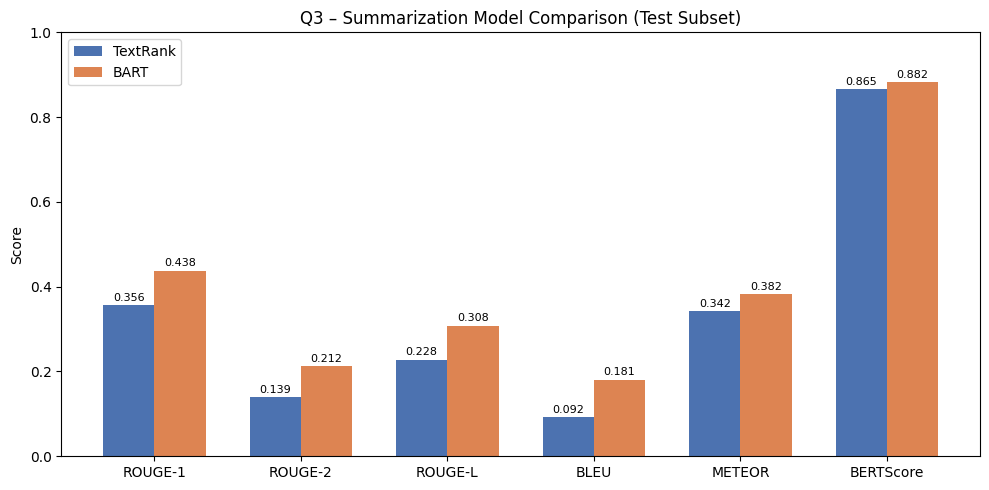


✅ Q3 tamamlandı! Sonuçları main.tex'e gir.


In [14]:
print("\n" + "═"*65)
print("  GENEL SONUÇLAR (Test Subset)")
print("═"*65)
print(f"  {'Metrik':<12} {'TextRank':>12} {'BART':>12}")
print("-"*65)
for key in ["rouge1","rouge2","rougeL","bleu","meteor","bertscore"]:
    print(f"  {key:<12} {metrics_textrank[key]:>12.4f} {metrics_bart[key]:>12.4f}")
print("═"*65)

# ── Radar / Bar Chart ────────────────────────────────────────────────────────
metrics_labels = ["ROUGE-1","ROUGE-2","ROUGE-L","BLEU","METEOR","BERTScore"]
tr_vals  = [metrics_textrank[k] for k in ["rouge1","rouge2","rougeL","bleu","meteor","bertscore"]]
bart_vals= [metrics_bart[k]     for k in ["rouge1","rouge2","rougeL","bleu","meteor","bertscore"]]

x = np.arange(len(metrics_labels))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, tr_vals,   w, label="TextRank", color="#4C72B0")
b2 = ax.bar(x + w/2, bart_vals, w, label="BART",     color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(metrics_labels)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Q3 – Summarization Model Comparison (Test Subset)")
ax.legend()
for bar in b1.patches + b2.patches:
    ax.annotate(f"{bar.get_height():.3f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("figures/q3_comparison.png", dpi=150)
plt.show()

print("\n✅ Q3 tamamlandı! Sonuçları main.tex'e gir.")